<a href="https://colab.research.google.com/github/beyzaturku/2209/blob/main/yolo_models/yolo8_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!pip install ultralytics

In [56]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [57]:
from ultralytics import YOLO

def train_yolo():
    model = YOLO('yolov8n.pt')

    results = model.train(
        data='/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml',
        epochs=50,
        imgsz=640,
        batch=16,
        project="/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train",
        name="yolov8",
        save=True,
        save_period=5,
        val=True
    )
    return model, results

In [26]:
def create_metrics_table(csv_path):
    # CSV dosyasını oku
    df = pd.read_csv(csv_path)

    # Önemli sütunları seç ve yeniden adlandır
    metrics_df = df[['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                     'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                     'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']].copy()

    # Sütun isimlerini sadeleştir
    metrics_df.columns = ['Epoch', 'Train_Box_Loss', 'Train_Cls_Loss', 'Train_DFL_Loss',
                         'Precision', 'Recall', 'mAP50', 'mAP50_95',
                         'Val_Box_Loss', 'Val_Cls_Loss', 'Val_DFL_Loss']

    print("Model Performans Metrikleri:")
    print(metrics_df.tail(10))  # Son 10 epoch
    return metrics_df

def visualize_results(df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss grafikleri (Train vs Val)
    axes[0,0].plot(df['Epoch'], df['Train_Box_Loss'], label='Train Box Loss', color='blue')
    axes[0,0].plot(df['Epoch'], df['Val_Box_Loss'], label='Val Box Loss', color='red')
    axes[0,0].set_title('Box Loss Eğrileri')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # mAP grafikleri
    axes[0,1].plot(df['Epoch'], df['mAP50'], label='mAP50', color='green')
    axes[0,1].plot(df['Epoch'], df['mAP50_95'], label='mAP50-95', color='orange')
    axes[0,1].set_title('mAP Metrikleri')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('mAP')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Precision ve Recall
    axes[1,0].plot(df['Epoch'], df['Precision'], label='Precision', color='purple')
    axes[1,0].plot(df['Epoch'], df['Recall'], label='Recall', color='brown')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Değer')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # Tüm Loss türleri
    axes[1,1].plot(df['Epoch'], df['Train_Box_Loss'], label='Box Loss')
    axes[1,1].plot(df['Epoch'], df['Train_Cls_Loss'], label='Cls Loss')
    axes[1,1].plot(df['Epoch'], df['Train_DFL_Loss'], label='DFL Loss')
    axes[1,1].set_title('Eğitim Loss Türleri')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('Loss')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # Son epoch özet tablosu
    final_metrics = df.iloc[-1]
    print(f"\nFinal Epoch ({int(final_metrics['Epoch'])}) Sonuçları:")
    print(f"mAP50: {final_metrics['mAP50']:.4f}")
    print(f"mAP50-95: {final_metrics['mAP50_95']:.4f}")
    print(f"Precision: {final_metrics['Precision']:.4f}")
    print(f"Recall: {final_metrics['Recall']:.4f}")

def test_single_image(model_path, image_path, conf_threshold=0.25, iou_threshold=0.45):
    model = YOLO(model_path)

    # Düşük threshold ile tahmin (daha fazla tespit için)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold)

    # Görselleştirme
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Sonuçları çiz
    annotated_img = results[0].plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img)
    plt.title(f'YOLO Tespiti (conf≥{conf_threshold}, iou≥{iou_threshold}) - {len(results[0].boxes) if results[0].boxes is not None else 0} nesne bulundu')
    plt.axis('off')
    plt.show()

    # Detay bilgiler
    if results[0].boxes is not None:
        print(f"\nToplam {len(results[0].boxes)} nesne tespit edildi:")
        print("-" * 40)
        for i, box in enumerate(results[0].boxes):
            conf = box.conf.item()
            cls = int(box.cls.item())
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            print(f"Nesne {i+1}: Sınıf {cls}, Güven: {conf:.3f}, Box: [{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
    else:
        print("Hiç nesne tespit edilmedi!")

    return results

def compare_thresholds(model_path, image_path):
    """Farklı confidence ve IOU threshold'larını karşılaştır"""
    thresholds = [
        (0.5, 0.5),   # Varsayılan (yüksek)
        (0.3, 0.4),   # Orta
        (0.1, 0.3)    # Düşük (daha hassas)
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, (conf, iou) in enumerate(thresholds):
        model = YOLO(model_path)
        results = model(image_path, conf=conf, iou=iou)

        annotated_img = results[0].plot()

        axes[i].imshow(annotated_img)
        axes[i].set_title(f'conf={conf}, iou={iou}\n{len(results[0].boxes) if results[0].boxes is not None else 0} tespit')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [58]:
import torch
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import cv2

print("1. Model eğitimi başlatılıyor...")
model, results = train_yolo()

1. Model eğitimi başlatılıyor...


100%|██████████| 6.25M/6.25M [00:00<00:00, 72.9MB/s]


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/altitude/high_alt_object_detection/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

train: Scanning /content/drive/MyDrive/altitude/high_alt_object_detection/dataset/labels/train.cache... 281 images, 0 backgrounds, 0 corrupt: 100%|██████████| 281/281 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      50/50      2.09G       1.05     0.5852     0.8044        115        640: 100%|██████████| 18/18 [00:01<00:00, 10.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  6.63it/s]

                   all         71        925       0.97      0.946      0.975      0.779



50 epochs completed in 0.036 hours.
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.77it/s]


                   all         71        925      0.971      0.947      0.975      0.784
                   car         71        912      0.963      0.894      0.956      0.632
                   bus         13         13      0.979          1      0.995      0.937
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8



2. CSV'den metrikler okunuyor...
Model Performans Metrikleri:
    Epoch  Train_Box_Loss  Train_Cls_Loss  Train_DFL_Loss  Precision   Recall  \
40     41         1.26042         0.69387         0.81586    0.95840  0.94562   
41     42         1.17852         0.65057         0.81647    0.96922  0.95033   
42     43         1.15729         0.63433         0.81164    0.95365  0.94572   
43     44         1.14656         0.62908         0.80814    0.95887  0.94793   
44     45         1.11517         0.61845         0.81294    0.95753  0.95175   
45     46         1.09519         0.60296         0.81387    0.95125  0.94957   
46     47         1.11260         0.60503         0.81651    0.95716  0.95175   
47     48         1.07508         0.58906         0.80824    0.96544  0.94952   
48     49         1.07984         0.59175         0.80639    0.97148  0.94711   
49     50         1.04951         0.58520         0.80442    0.97020  0.94642   

      mAP50  mAP50_95  Val_Box_Loss  Val_Cls_

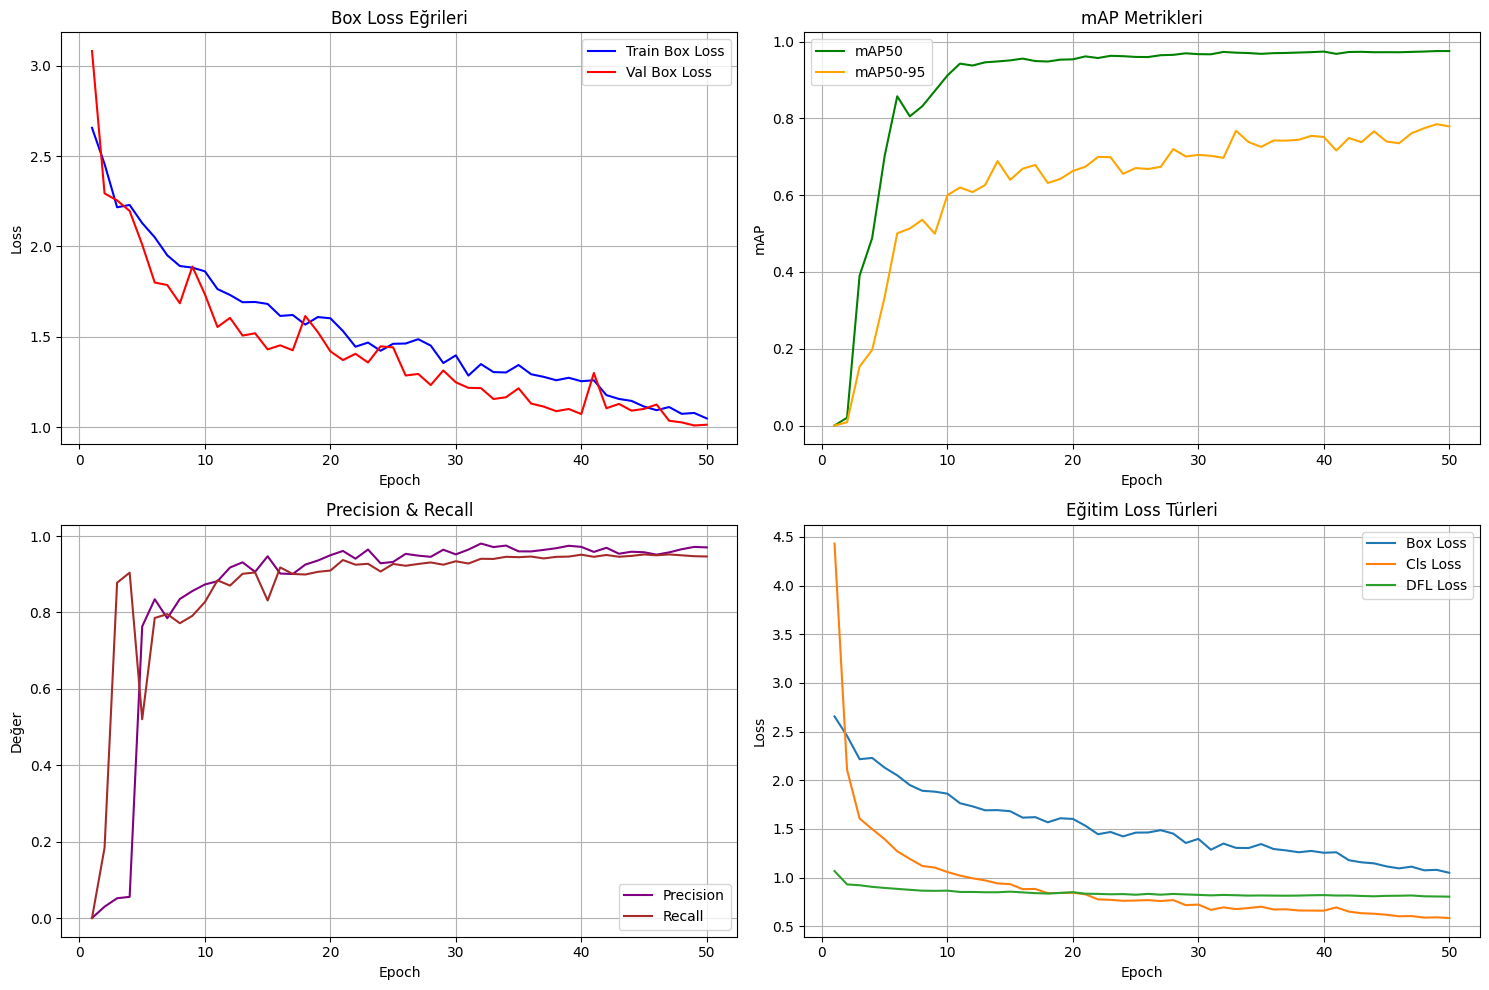


Final Epoch (50) Sonuçları:
mAP50: 0.9752
mAP50-95: 0.7790
Precision: 0.9702
Recall: 0.9464

4. Tek görsel test ediliyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 6 cars, 19.6ms
Speed: 2.4ms preprocess, 19.6ms inference, 1.9ms postprocess per image at shape (1, 3, 352, 640)


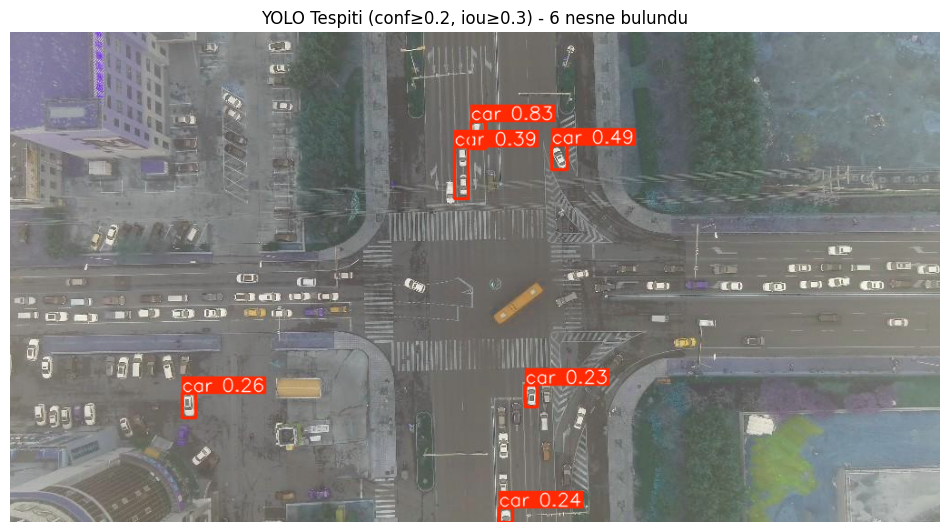


Toplam 6 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.831, Box: [507,99,524,129]
Nesne 2: Sınıf 0, Güven: 0.489, Box: [596,126,614,153]
Nesne 3: Sınıf 0, Güven: 0.389, Box: [489,127,505,185]
Nesne 4: Sınıf 0, Güven: 0.262, Box: [190,399,204,425]
Nesne 5: Sınıf 0, Güven: 0.244, Box: [539,524,554,540]
Nesne 6: Sınıf 0, Güven: 0.227, Box: [567,390,581,414]

4. Farklı threshold'lar karşılaştırılıyor...

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 1 car, 9.0ms
Speed: 2.0ms preprocess, 9.0ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 3 cars, 8.9ms
Speed: 1.9ms preprocess, 8.9ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_datase

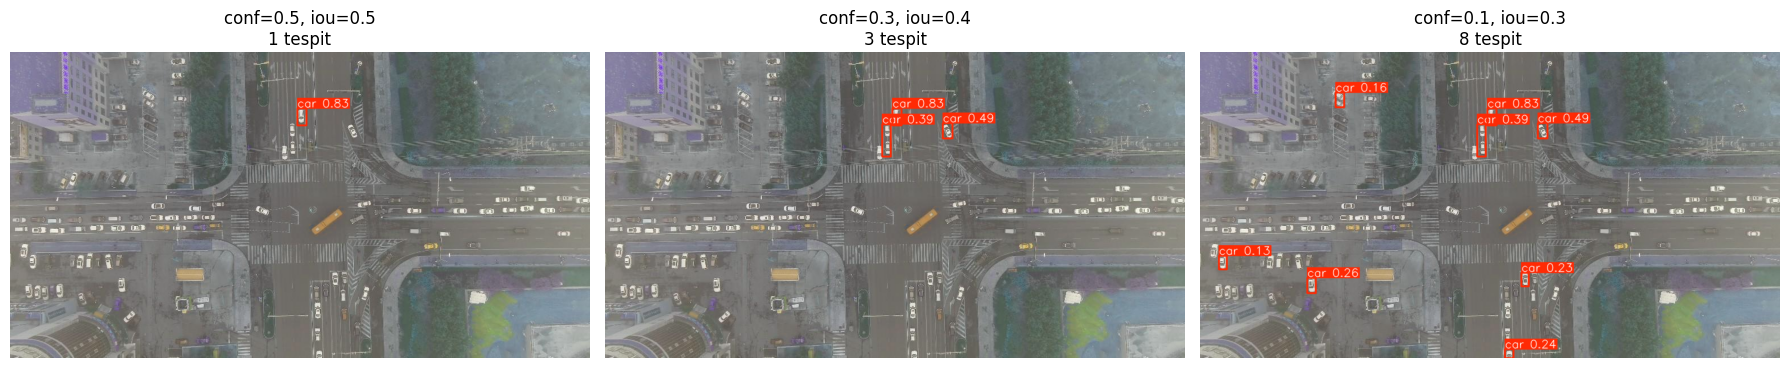

In [59]:
print("\n2. CSV'den metrikler okunuyor...")
df = create_metrics_table('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/results.csv')

    # Görselleştir
print("\n3. Sonuçlar görselleştiriliyor...")
visualize_results(df)

    # Test et
print("\n4. Tek görsel test ediliyor...")
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.2, iou_threshold=0.3)

print("\n4. Farklı threshold'lar karşılaştırılıyor...")
compare_thresholds('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg')


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 8 cars, 67.2ms
Speed: 2.0ms preprocess, 67.2ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


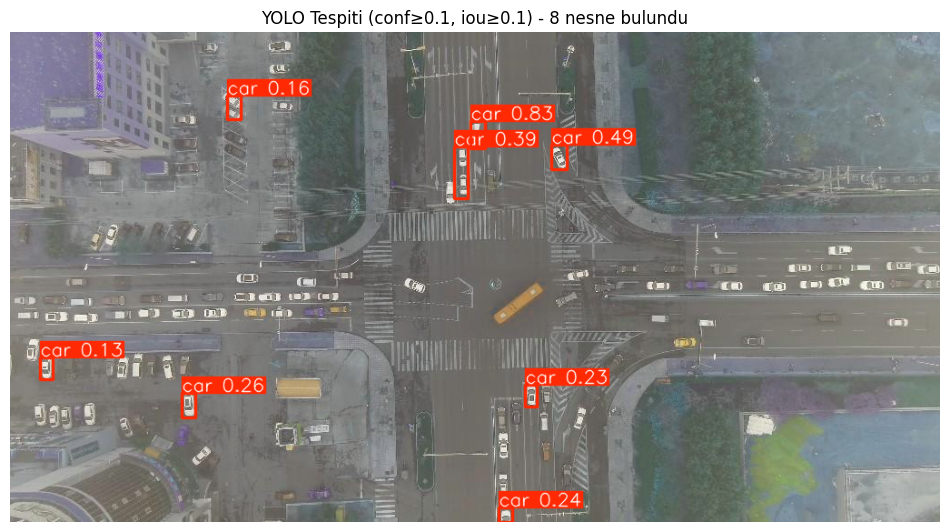


Toplam 8 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.831, Box: [507,99,524,129]
Nesne 2: Sınıf 0, Güven: 0.489, Box: [596,126,614,153]
Nesne 3: Sınıf 0, Güven: 0.389, Box: [489,127,505,185]
Nesne 4: Sınıf 0, Güven: 0.262, Box: [190,399,204,425]
Nesne 5: Sınıf 0, Güven: 0.244, Box: [539,524,554,540]
Nesne 6: Sınıf 0, Güven: 0.227, Box: [567,390,581,414]
Nesne 7: Sınıf 0, Güven: 0.157, Box: [240,71,255,97]
Nesne 8: Sınıf 0, Güven: 0.128, Box: [33,359,47,384]


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [60]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.1, iou_threshold=0.1)


image 1/1 /content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg: 352x640 89 cars, 1 bus, 8.1ms
Speed: 2.0ms preprocess, 8.1ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


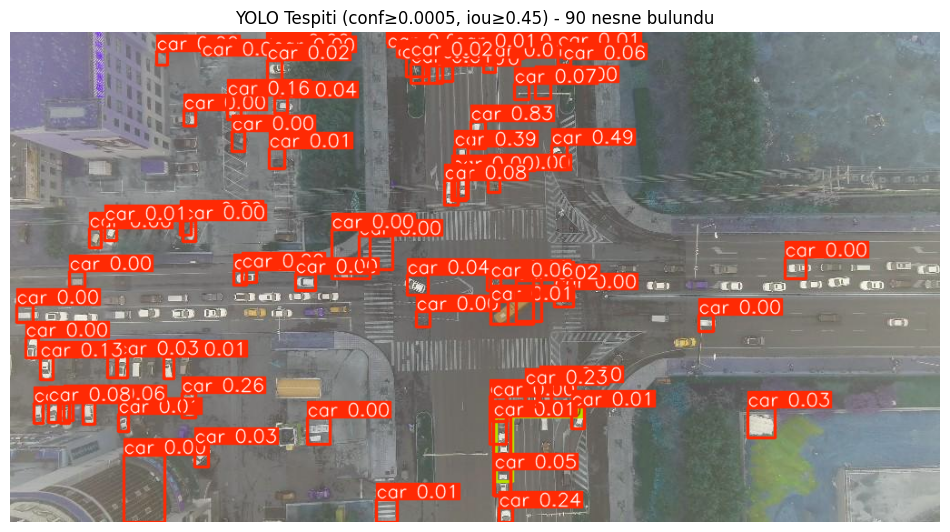


Toplam 90 nesne tespit edildi:
----------------------------------------
Nesne 1: Sınıf 0, Güven: 0.831, Box: [507,99,524,129]
Nesne 2: Sınıf 0, Güven: 0.489, Box: [596,126,614,153]
Nesne 3: Sınıf 0, Güven: 0.389, Box: [489,127,505,185]
Nesne 4: Sınıf 0, Güven: 0.262, Box: [190,399,204,425]
Nesne 5: Sınıf 0, Güven: 0.244, Box: [539,524,554,540]
Nesne 6: Sınıf 0, Güven: 0.227, Box: [567,390,581,414]
Nesne 7: Sınıf 0, Güven: 0.157, Box: [240,71,255,97]
Nesne 8: Sınıf 0, Güven: 0.128, Box: [33,359,47,384]
Nesne 9: Sınıf 0, Güven: 0.079, Box: [478,164,493,191]
Nesne 10: Sınıf 0, Güven: 0.077, Box: [43,409,54,430]
Nesne 11: Sınıf 0, Güven: 0.069, Box: [556,58,572,76]
Nesne 12: Sınıf 0, Güven: 0.063, Box: [609,14,623,29]
Nesne 13: Sınıf 0, Güven: 0.055, Box: [530,272,576,323]
Nesne 14: Sınıf 0, Güven: 0.055, Box: [81,407,94,433]
Nesne 15: Sınıf 0, Güven: 0.046, Box: [534,482,551,512]
Nesne 16: Sınıf 0, Güven: 0.037, Box: [438,268,460,291]
Nesne 17: Sınıf 0, Güven: 0.037, Box: [292,74,306,90]

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'car', 1: 'vehicle', 2: 'truck', 3: 'bus'}
 obb: None
 orig_img: array([[[130, 124, 155],
         [130, 124, 155],
         [131, 125, 156],
         ...,
         [130, 146, 158],
         [136, 152, 164],
         [142, 158, 170]],
 
        [[133, 127, 158],
         [133, 127, 158],
         [133, 127, 158],
         ...,
         [132, 148, 160],
         [136, 152, 164],
         [139, 155, 167]],
 
        [[136, 130, 161],
         [136, 130, 161],
         [135, 129, 160],
         ...,
         [134, 150, 162],
         [135, 151, 163],
         [136, 152, 164]],
 
        ...,
 
        [[139, 136, 131],
         [137, 134, 129],
         [134, 131, 126],
         ...,
         [134, 139, 130],
         [133, 138, 129],
         [133, 138, 129]],
 
        [[139, 136, 132],
         [136, 133, 129],
         [132, 129, 125],

In [61]:
test_single_image('/content/drive/MyDrive/altitude/high_alt_object_detection/yolo8_train/yolov8/weights/best.pt', '/content/drive/MyDrive/altitude/high_alt_object_detection/test_dataset/high_alt_images/M0701_img000377.jpg', conf_threshold=0.0005)